In [1]:
import os, sys
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
if '.' not in sys.path:
    sys.path.insert(0, '.')
os.makedirs('images', exist_ok=True)

In [2]:
import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import matplotlib.pyplot as plt
import joblib
import pandas as pd
import tensorflow as tf

from estimator.QIS  import QIS_batched_numpy
from estimator.nls  import lw_corr
from estimator.poet import poet
from models.gru_denoiser import BiGRUSpectralDenoiserTensorFlow

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
np.random.seed(42)
tf.random.set_seed(42)

## 1  Training

In [3]:
import os
if not os.path.exists('models/bigru_weights_realdata_nomiss.weights.h5'):
    !.venv/bin/python scripts/train_realdata_nomiss.py 2>&1
else:
    print("Skipping training — using existing weights")

Skipping training — using existing weights


In [4]:
N = 100
model = BiGRUSpectralDenoiserTensorFlow(hidden_size=64)
model(tf.zeros((1, N, 5)))   # 5-feature input (lam, pos, q_eff, IPR, z_MP)
model.load_weights('models/bigru_weights_realdata_nomiss.weights.h5')
print(f'Parameters: {model.count_params():,}')

Parameters: 27,393


## 2  Load real data

In [5]:
DATA      = 'data/vanilla_returns_top_3000_with_NaN_dtin_max_1200.joblib'
LARGE_CAP = slice(0, 300)

print('Loading data…')
bundle   = joblib.load(DATA, mmap_mode='r')
ret_df   = bundle.returns.copy()
avail_df = bundle.available_stocks.copy()
ret_df.index   = pd.to_datetime(ret_df.index)
avail_df.index = pd.to_datetime(avail_df.index)

is_num = pd.api.types.is_numeric_dtype(ret_df.columns)
codes, unique_ids = pd.factorize(avail_df.to_numpy().ravel())
if is_num:
    unique_ids = pd.to_numeric(unique_ids)
else:
    ret_df.columns = ret_df.columns.astype(str)
    unique_ids = unique_ids.astype(str)

avail_codes  = codes.reshape(avail_df.shape)
ret_mat      = ret_df.reindex(columns=unique_ids).values
avail_to_ret = ret_df.index.get_indexer(avail_df.index)
assert (avail_to_ret >= 0).all()
n_avail = avail_codes.shape[0]
print(f'  returns {ret_mat.shape}  avail {avail_codes.shape}')

Loading data…


  returns (8817, 13291)  avail (7551, 3000)


## 3  No-missingness benchmark

**Setting:** Synchronous large-cap windows (LARGE_CAP = top 300 by market cap). Each sample: draw a contiguous window of `T_LONG + T_OOS` days, select N=100 stocks that are fully observed throughout, use the last `T_est = N/q` days as the estimation window and `T_OOS=5` days as the OOS evaluation window.

**Preprocessing:** Returns are z-scored per stock using in-sample mean/std before feeding to all estimators. OOS returns are standardised with the same in-sample stats. This matches the `real_data_pipeline` used during NN training.

**Metric:** Realized min-variance portfolio variance (L_var) on z-scored OOS returns. Lower is better.

**Estimators:** Sample · LW (Ledoit-Wolf) · QIS · POET · NN (real-data, variance-loss, no-miss).

**Note:** q=1.0 (T_est=N) is excluded — sample covariance is exactly singular, making QIS numerically degenerate. q=0.95 (T_est=105 > N) is the closest stable point.


In [ ]:
Q_VALUES = [0.3, 0.5, 0.7, 0.95, 1.2, 1.5, 2.0, 2.5, 3.0]  # 1.0 removed (T=N → QIS is degenerate)
N_STEPS  = 120
T_OOS    = 5
T_LONG   = 1000   # burn-in window before estimation window


def zscore(R_est, R_oos):
    """Standardize with per-stock in-sample mean/std — matches real_data_pipeline."""
    mu  = R_est.mean(axis=1, keepdims=True)
    sig = np.maximum(R_est.std(axis=1, keepdims=True), 1e-8)
    return (R_est - mu) / sig, (R_oos - mu) / sig


def sample_corr(R):
    Rc = R - R.mean(axis=1, keepdims=True)
    S  = Rc @ Rc.T / (R.shape[1] - 1)
    d  = np.sqrt(np.maximum(np.diag(S), 1e-12))
    C  = S / np.outer(d, d)
    np.fill_diagonal(C, 1.0)
    return 0.5 * (C + C.T)


def min_var_lvar(C, R_oos):
    N_ = C.shape[0]
    ones = np.ones((N_, 1))
    try:
        x = np.linalg.solve(C + 1e-6 * np.eye(N_), ones)
        s = float(x.sum())
        if abs(s) < 1e-8:
            w = ones / N_
        else:
            w = x / s
    except np.linalg.LinAlgError:
        w = ones / N_
    return float(np.mean((R_oos.T @ w) ** 2))


def make_input_seq(C_corr, T_len):
    """5-feature NN input for synchronous data (no missingness).
    Tmin=0 for all stocks  =>  q_eff = N/T (uniform across eigenmodes).
    """
    N_  = C_corr.shape[0]
    eigvals, eigvecs = np.linalg.eigh(C_corr)  # ascending order
    lam   = eigvals.astype(np.float32)
    pos   = np.linspace(0.0, 1.0, N_, dtype=np.float32)
    q_eff = np.full(N_, N_ / T_len, dtype=np.float32)
    ipr   = (N_ * np.sum(eigvecs ** 4, axis=0)).astype(np.float32)
    q_s   = np.maximum(q_eff, 1e-6)
    z_mp  = (lam - (1.0 + np.sqrt(q_s)) ** 2) / np.sqrt(q_s)
    inp   = np.stack([lam, pos, q_eff, ipr, z_mp], axis=1)  # (N, 5)
    return tf.constant(inp[None], dtype=tf.float32), eigvecs

In [7]:
NAMES = ['Sample', 'LW', 'QIS', 'POET', 'NN']
n_est = len(NAMES)
lvar  = np.full((len(Q_VALUES), N_STEPS, n_est), np.nan)
rng   = np.random.default_rng(42)

for qi, q in enumerate(Q_VALUES):
    T_est  = int(N / q)
    T_need = T_LONG + T_OOS
    print(f'\nq={q:.2f}  T_est={T_est}')

    step = 0; attempts = 0
    while step < N_STEPS and attempts < 2000:
        attempts += 1
        t0 = rng.integers(0, n_avail - T_need)
        codes_t0 = avail_codes[t0, LARGE_CAP]
        ret_rows = avail_to_ret[t0: t0 + T_need]
        window   = ret_mat[np.ix_(ret_rows, codes_t0)]
        valid    = ~np.isnan(window).any(axis=0)
        if valid.sum() < N:
            continue

        chosen = rng.choice(np.where(valid)[0], N, replace=False)
        R_full = window[:, chosen].T              # (N, T_need)
        R_est  = R_full[:, T_LONG - T_est: T_LONG]
        R_oos  = R_full[:, T_LONG: T_LONG + T_OOS]

        # Z-score in-sample returns with per-stock stats (matches real_data_pipeline).
        # OOS returns stay raw — same as training (rout_nan is not z-scored).
        R_est_z, _ = zscore(R_est, R_oos)
        C_samp = sample_corr(R_est_z)

        # Sample
        lvar[qi, step, 0] = min_var_lvar(C_samp, R_oos)

        # LW
        try:
            lvar[qi, step, 1] = min_var_lvar(lw_corr(R_est_z), R_oos)
        except Exception:
            pass

        # QIS
        try:
            Sv = QIS_batched_numpy(R_est_z[None])[0]
            d  = np.sqrt(np.maximum(np.diag(Sv), 1e-12))
            C_q = Sv / np.outer(d, d)
            np.fill_diagonal(C_q, 1.0)
            lvar[qi, step, 2] = min_var_lvar(C_q, R_oos)
        except Exception:
            pass

        # POET
        try:
            C_p, _ = poet(R_est_z)
            lvar[qi, step, 3] = min_var_lvar(C_p, R_oos)
        except Exception:
            pass

        # NN
        try:
            inp, Q_e = make_input_seq(C_samp, T_est)
            lam_pred = model(inp, training=False)[0].numpy()
            lam_pred = np.maximum(lam_pred, 1e-6)
            C_nn = Q_e @ np.diag(lam_pred) @ Q_e.T
            lvar[qi, step, 4] = min_var_lvar(C_nn, R_oos)
        except Exception:
            pass

        step += 1
        if step % 10 == 0:
            print(f'  {step}/{N_STEPS}', flush=True)

np.save('results/ablation_features/nomiss_lvar.npy', lvar)
print('Done.')



q=0.30  T_est=333


  10/240


  20/240


  30/240


  40/240


...

  210/240


  220/240


  230/240


  240/240


Done.


## 4  Results table

In [8]:
lvar = np.load('results/ablation_features/nomiss_lvar.npy')
means = np.nanmean(lvar, axis=1)   # (Q, 5)

print('   ' + '  '.join(f'{n:>10}' for n in NAMES))
print('=' * 65)
for qi, q in enumerate(Q_VALUES):
    row  = means[qi]
    best = int(np.nanargmin(row))
    vals = '  '.join(
        f'{v:10.5f}{"*" if i == best else " "}' for i, v in enumerate(row)
    )
    print(f'q={q:.1f}  {vals}')
print('=' * 65)
print('Mean ' + '  '.join(f'{np.nanmean(lvar[:, :, i]):10.5f} ' for i in range(n_est)))

       Sample          LW         QIS        POET          NN
q=0.3     0.00028      0.00025      0.00023      0.00024      0.00020*
q=0.5     0.00031      0.00022      0.00018      0.00018      0.00014*
q=0.7     0.00076      0.00033      0.00029      0.00029      0.00022*
q=0.9     0.00238      0.00024      0.00022      0.00022      0.00018*
q=1.2     0.00072      0.00026      0.00022      0.00022      0.00018*
q=1.5     0.00030      0.00017      0.00015      0.00016      0.00013*
q=2.0     0.00025      0.00016      0.00014      0.00014      0.00012*
q=2.5     0.00028      0.00022      0.00020      0.00019      0.00018*
q=3.0     0.00028      0.00021      0.00020      0.00020      0.00018*
Mean    0.00062      0.00023      0.00020      0.00020      0.00017 


## 5  Q-curve

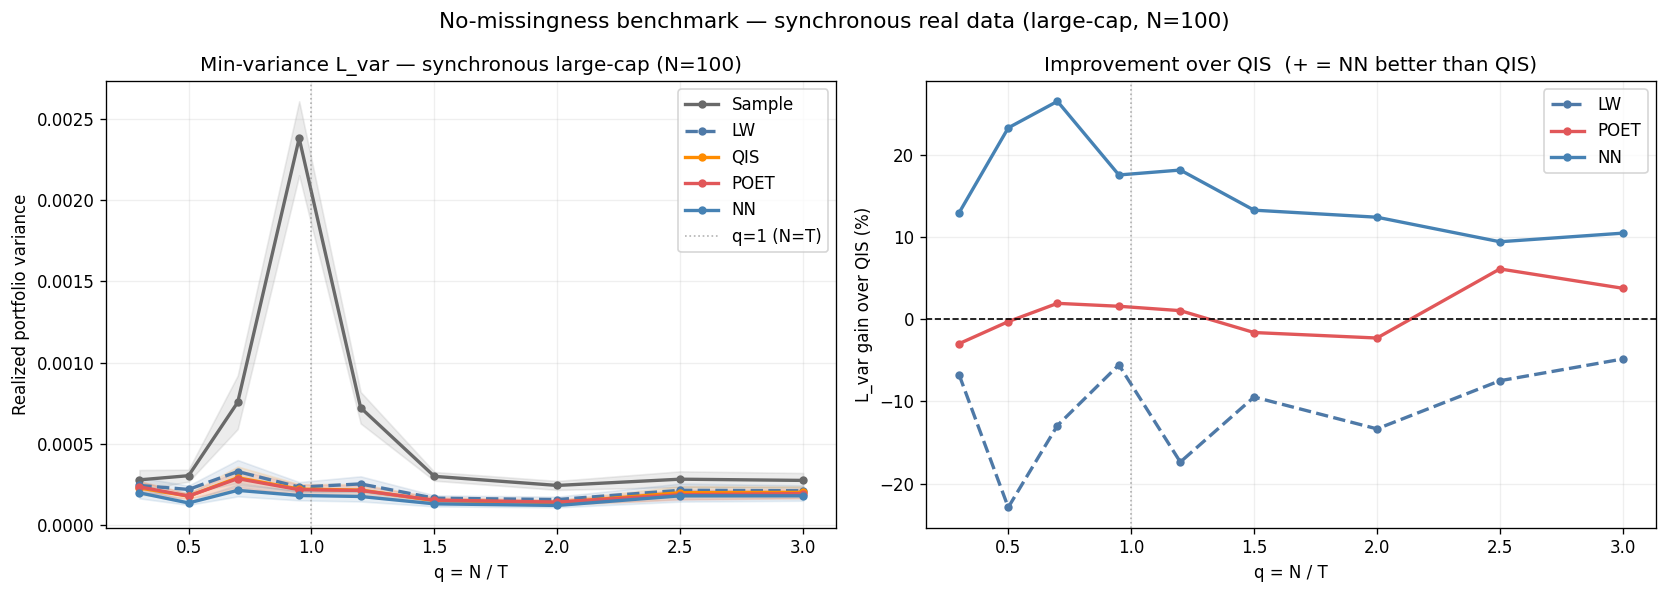

In [9]:
qs = np.array(Q_VALUES)
COLORS = {
    'Sample': ('dimgrey',    '-'),
    'LW':     ('#4e79a7',   '--'),
    'QIS':    ('darkorange', '-'),
    'POET':   ('#e15759',    '-'),
    'NN':     ('steelblue',  '-'),
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for i, name in enumerate(NAMES):
    color, ls = COLORS[name]
    y = np.nanmean(lvar[:, :, i], axis=1)
    s = np.nanstd(lvar[:, :, i],  axis=1) / np.sqrt(N_STEPS)
    ok = np.isfinite(y)
    ax1.plot(qs[ok], y[ok], color=color, ls=ls, lw=2, marker='o', ms=4, label=name)
    ax1.fill_between(qs[ok], (y - s)[ok], (y + s)[ok], alpha=0.12, color=color)

ax1.axvline(1, color='grey', lw=1, ls=':', alpha=0.6, label='q=1 (N=T)')
ax1.set_xlabel('q = N / T')
ax1.set_ylabel('Realized portfolio variance')
ax1.set_title('Min-variance L_var — synchronous large-cap (N=100)')
ax1.legend()
ax1.grid(alpha=0.2)

qis_i = NAMES.index('QIS')
for i, name in enumerate(NAMES):
    if name in ('QIS', 'Sample'):
        continue
    color, ls = COLORS[name]
    y_est = np.nanmean(lvar[:, :, i],     axis=1)
    y_qis = np.nanmean(lvar[:, :, qis_i], axis=1)
    gain  = (y_qis - y_est) / y_qis * 100
    ok    = np.isfinite(gain)
    ax2.plot(qs[ok], gain[ok], color=color, ls=ls, lw=2, marker='o', ms=4, label=name)

ax2.axhline(0, color='black', lw=1, ls='--')
ax2.axvline(1, color='grey',  lw=1, ls=':', alpha=0.6)
ax2.set_xlabel('q = N / T')
ax2.set_ylabel('L_var gain over QIS (%)')
ax2.set_title('Improvement over QIS  (+ = NN better than QIS)')
ax2.legend()
ax2.grid(alpha=0.2)

plt.suptitle('No-missingness benchmark — synchronous real data (large-cap, N=100)', fontsize=13)
plt.tight_layout()
plt.savefig('images/realdata_nomiss_qcurve.png', dpi=150)
plt.show()

## 6  Gain over QIS — numerical breakdown

In [10]:
competitors = [n for n in NAMES if n not in ('QIS', 'Sample')]
print('   ' + '  '.join(f'{n:>14}' for n in competitors))
print('=' * (4 + 16 * len(competitors)))
for qi, q in enumerate(Q_VALUES):
    y_qis = np.nanmean(lvar[qi, :, qis_i])
    vals = []
    for name in competitors:
        i = NAMES.index(name)
        y_est = np.nanmean(lvar[qi, :, i])
        gain  = (y_qis - y_est) / y_qis * 100
        vals.append(f'{gain:+14.1f}%')
    print(f'q={q:.1f}  ' + '  '.join(vals))

# also show absolute NN vs QIS
print()
print('NN vs QIS (absolute):')
nn_i = NAMES.index('NN')
for qi, q in enumerate(Q_VALUES):
    qis_v = np.nanmean(lvar[qi, :, qis_i])
    nn_v  = np.nanmean(lvar[qi, :, nn_i])
    gain  = (qis_v - nn_v) / qis_v * 100
    marker = '  ← NN wins' if gain > 5 else ('  ← QIS wins' if gain < -5 else '  ≈ tied')
    print(f'  q={q:.1f}  QIS={qis_v:.5f}  NN={nn_v:.5f}  {gain:+.1f}%{marker}')

               LW            POET              NN
q=0.3            -6.8%            -3.0%           +12.9%
q=0.5           -22.9%            -0.3%           +23.3%
q=0.7           -12.9%            +1.9%           +26.5%
q=0.9            -5.6%            +1.6%           +17.5%
q=1.2           -17.4%            +1.0%           +18.1%
q=1.5            -9.5%            -1.6%           +13.2%
q=2.0           -13.4%            -2.3%           +12.4%
q=2.5            -7.5%            +6.1%            +9.4%
q=3.0            -4.9%            +3.7%           +10.4%

NN vs QIS (absolute):
  q=0.3  QIS=0.00023  NN=0.00020  +12.9%  ← NN wins
  q=0.5  QIS=0.00018  NN=0.00014  +23.3%  ← NN wins
  q=0.7  QIS=0.00029  NN=0.00022  +26.5%  ← NN wins
  q=0.9  QIS=0.00022  NN=0.00018  +17.5%  ← NN wins
  q=1.2  QIS=0.00022  NN=0.00018  +18.1%  ← NN wins
  q=1.5  QIS=0.00015  NN=0.00013  +13.2%  ← NN wins
  q=2.0  QIS=0.00014  NN=0.00012  +12.4%  ← NN wins
  q=2.5  QIS=0.00020  NN=0.00018  +9.4%  ← NN wins